# Phase Time Summary — NNR (Multiple Sites)

Average phase duration (seconds) per hour of day, across all available sites.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

BASE_DIR = (
    r"C:\Users\IvanVelilla\Mobility Lab Limited"
    r"\Projects - 1034 - Western LX Aimsun"
    r"\New North Road\Received\SCATS NNR"
)

# Define sites: label -> filename
SITES = {
    "2050 (10 Sep 2025)": "phasetime_2050_20250910.csv",
    "2409 (17 Sep 2025)": "phasetime_2409_20250917.csv",
}

def load_site(filename):
    df = pd.read_csv(f"{BASE_DIR}\\{filename}")
    df["Start"] = pd.to_datetime(
        df["Start"].str.replace(r"\s+NZST$", "", regex=True),
        format="%A, %d %B %Y, %I:%M:%S %p",
    )
    df["Hour"] = df["Start"].dt.hour
    df["Duration (s)"] = pd.to_numeric(df["Duration (s)"], errors="coerce")
    return df

site_data = {label: load_site(fname) for label, fname in SITES.items()}

for label, df in site_data.items():
    print(f"[{label}]  rows={len(df):,}  phases={sorted(df['Phase'].unique())}")
    display(df.head(3))

[2050 (10 Sep 2025)]  rows=3,897  phases=['<A>', 'B', 'C', 'D', 'Unknown']


,Phase,Duration (s),Start,End,Gapped,Hour
0,Unknown,10,2025-09-10 00:00:00,"Wednesday, 10 September 2025, 12:00:10 AM NZST",NaN,0
1,B,24,2025-09-10 00:00:10,"Wednesday, 10 September 2025, 12:00:34 AM NZST",NaN,0
2,C,14,2025-09-10 00:00:34,"Wednesday, 10 September 2025, 12:00:48 AM NZST",Yes,0


[2409 (17 Sep 2025)]  rows=3,299  phases=['<A>', 'D', 'E', 'F', 'Unknown']


,Phase,Duration (s),Start,End,Gapped,Hour
0,Unknown,13,2025-09-17 00:00:00,"Wednesday, 17 September 2025, 12:00:13 AM NZST",NaN,0
1,<A>,14,2025-09-17 00:00:13,"Wednesday, 17 September 2025, 12:00:27 AM NZST",Yes,0
2,D,11,2025-09-17 00:00:27,"Wednesday, 17 September 2025, 12:00:38 AM NZST",Yes,0


## Average Phase Duration per Hour

In [7]:
def build_pivot(df):
    pivot = (
        df.groupby(["Hour", "Phase"])["Duration (s)"]
        .mean()
        .round(1)
        .unstack("Phase")
    )
    pivot.index = pivot.index.map(lambda h: f"{h:02d}:00")
    pivot.index.name = "Hour"
    return pivot

def build_counts(df):
    counts = (
        df.groupby(["Hour", "Phase"])["Duration (s)"]
        .count()
        .unstack("Phase")
    )
    counts.index = counts.index.map(lambda h: f"{h:02d}:00")
    counts.index.name = "Hour"
    return counts

def build_summary(df):
    return (
        df.groupby("Phase")["Duration (s)"]
        .agg(Count="count", Mean="mean", Median="median", Std="std", Min="min", Max="max")
        .round(1)
    )

pivots   = {label: build_pivot(df)   for label, df in site_data.items()}
counts   = {label: build_counts(df)  for label, df in site_data.items()}
summaries = {label: build_summary(df) for label, df in site_data.items()}

for label, pivot in pivots.items():
    print(f"\n=== {label} — Avg Duration (s) ===")
    display(pivot)


=== 2050 (10 Sep 2025) — Avg Duration (s) ===


Phase,<A>,B,C,D,Unknown
Hour,,,,,
00:00,23.8,29.0,12.2,20.3,10.0
01:00,44.3,23.2,12.0,14.2,NaN
02:00,17.3,37.3,11.8,10.8,NaN
03:00,23.3,30.0,11.2,15.0,NaN
04:00,40.2,21.1,12.0,13.0,NaN
05:00,23.5,22.7,13.0,13.2,NaN
06:00,17.1,27.4,14.7,13.6,NaN
07:00,18.5,30.9,15.3,14.8,NaN
08:00,32.2,34.6,20.1,13.9,NaN



=== 2409 (17 Sep 2025) — Avg Duration (s) ===


Phase,<A>,D,E,F,Unknown
Hour,,,,,
00:00,65.0,11.8,11.9,11.2,13.0
01:00,105.1,11.2,11.3,10.8,NaN
02:00,165.2,10.9,11.3,11.0,NaN
03:00,169.6,11.3,11.0,11.0,NaN
04:00,136.4,10.9,11.8,11.0,NaN
05:00,41.3,12.5,12.7,10.9,NaN
06:00,28.1,14.2,13.7,11.6,NaN
07:00,38.7,17.0,15.7,12.1,NaN
08:00,55.4,23.2,16.5,11.8,NaN


In [8]:
for label, c in counts.items():
    print(f"\n=== {label} — Count ===")
    display(c)


=== 2050 (10 Sep 2025) — Count ===


Phase,<A>,B,C,D,Unknown
Hour,,,,,
00:00,66.0,57.0,24.0,7.0,1.0
01:00,51.0,46.0,14.0,5.0,NaN
02:00,63.0,61.0,13.0,6.0,NaN
03:00,68.0,61.0,13.0,3.0,NaN
04:00,55.0,53.0,16.0,6.0,NaN
05:00,66.0,54.0,38.0,25.0,NaN
06:00,57.0,54.0,45.0,35.0,NaN
07:00,48.0,46.0,44.0,42.0,NaN
08:00,36.0,36.0,35.0,36.0,NaN



=== 2409 (17 Sep 2025) — Count ===


Phase,<A>,D,E,F,Unknown
Hour,,,,,
00:00,47.0,25.0,19.0,5.0,1.0
01:00,31.0,21.0,7.0,5.0,NaN
02:00,20.0,11.0,6.0,4.0,NaN
03:00,21.0,10.0,10.0,1.0,NaN
04:00,23.0,16.0,8.0,1.0,NaN
05:00,63.0,37.0,33.0,9.0,NaN
06:00,73.0,52.0,48.0,14.0,NaN
07:00,49.0,42.0,42.0,27.0,NaN
08:00,34.0,35.0,34.0,29.0,NaN


## Charts

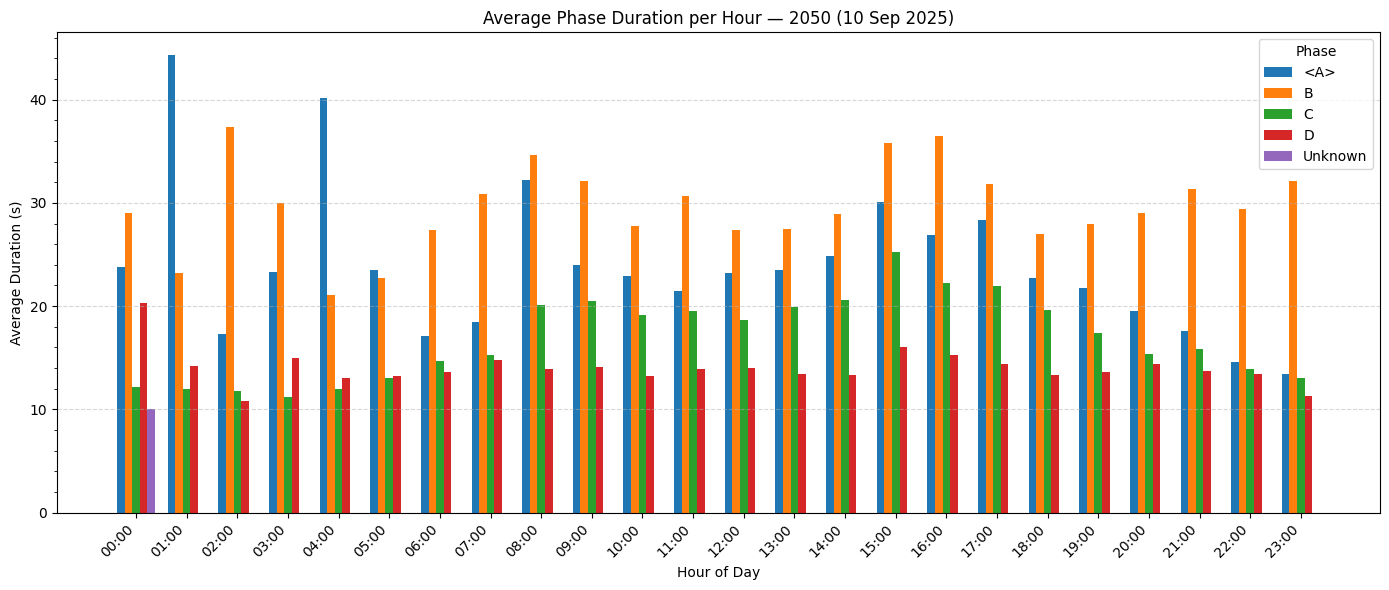

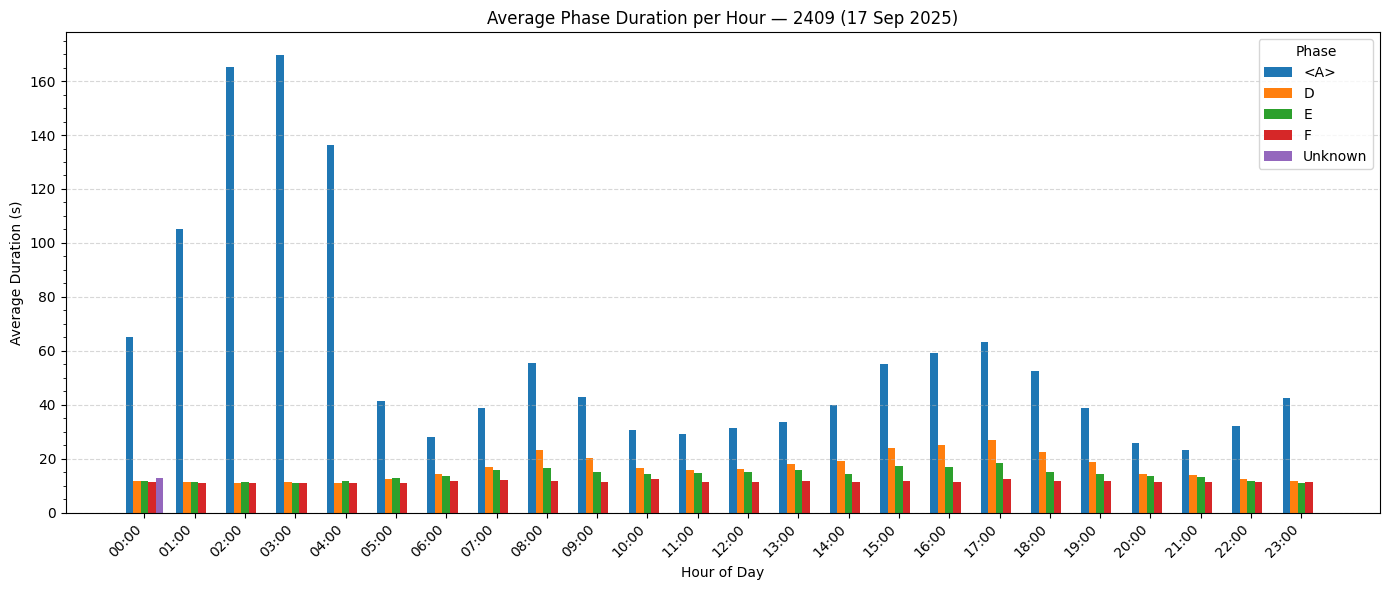

In [9]:
# --- Grouped bar chart per site ---
for label, pivot in pivots.items():
    phases = pivot.columns.tolist()
    x = np.arange(len(pivot))
    width = 0.15

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, phase in enumerate(phases):
        offset = (i - len(phases) / 2 + 0.5) * width
        ax.bar(x + offset, pivot[phase].fillna(0), width=width, label=phase)

    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Average Duration (s)")
    ax.set_title(f"Average Phase Duration per Hour — {label}")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right")
    ax.legend(title="Phase")
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

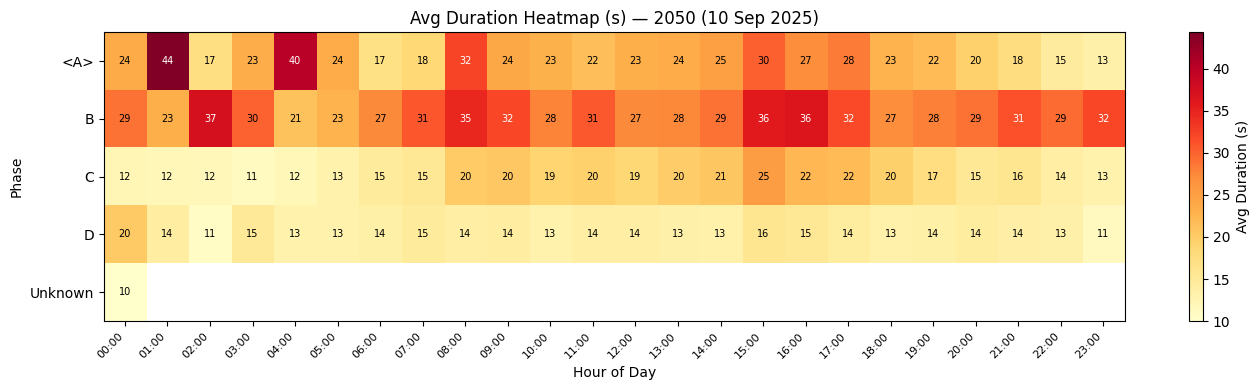

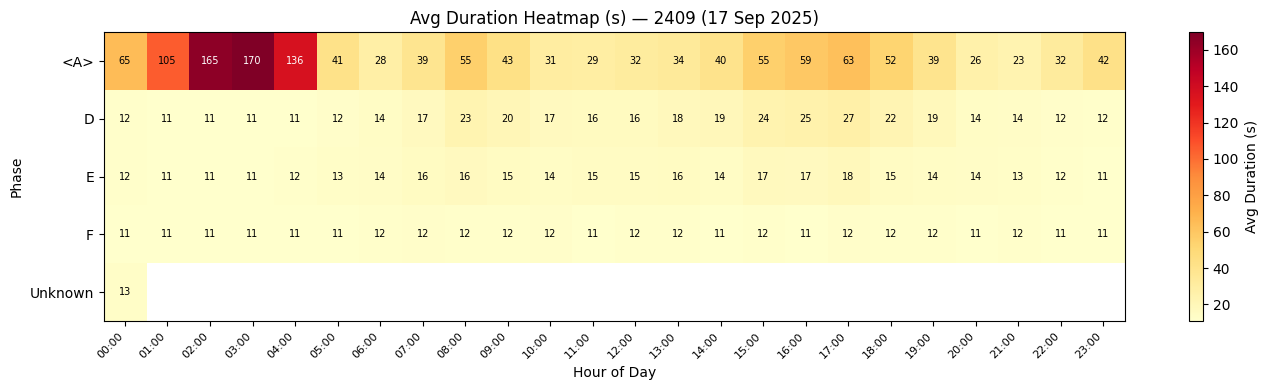

In [10]:
# --- Heatmap per site ---
for label, pivot in pivots.items():
    phases = pivot.columns.tolist()
    data = pivot.T.values.astype(float)

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(data, aspect="auto", cmap="YlOrRd")

    ax.set_xticks(range(len(pivot)))
    ax.set_xticklabels(pivot.index, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(phases)))
    ax.set_yticklabels(phases)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Phase")
    ax.set_title(f"Avg Duration Heatmap (s) — {label}")

    plt.colorbar(im, ax=ax, label="Avg Duration (s)")

    valid = data[~np.isnan(data)]
    threshold = valid.max() * 0.7 if len(valid) else 1
    for row in range(len(phases)):
        for col in range(len(pivot)):
            val = data[row, col]
            if not np.isnan(val):
                ax.text(col, row, f"{val:.0f}", ha="center", va="center", fontsize=7,
                        color="white" if val >= threshold else "black")

    plt.tight_layout()
    plt.show()

## Overall Summary Statistics by Phase

In [11]:
for label, s in summaries.items():
    print(f"\n=== {label} — Overall Summary ===")
    display(s)


=== 2050 (10 Sep 2025) — Overall Summary ===


,Count,Mean,Median,Std,Min,Max
Phase,,,,,,
<A>,1189,23.5,20.0,20.6,9,267
B,1139,29.5,30.0,9.4,14,57
C,856,17.5,17.0,4.8,10,39
D,712,13.9,13.0,3.4,10,59
Unknown,1,10.0,10.0,NaN,10,10



=== 2409 (17 Sep 2025) — Overall Summary ===


,Count,Mean,Median,Std,Min,Max
Phase,,,,,,
<A>,1170,46.7,35.0,51.2,11,561
D,916,16.9,15.0,5.8,10,41
E,766,14.5,14.0,3.2,7,34
F,446,11.6,11.0,1.3,10,20
Unknown,1,13.0,13.0,NaN,13,13


## Export to Excel

In [12]:
OUTPUT_PATH = 'outputs/phasetime_summary.xlsx'

# Sheet names: Excel limit is 31 chars — use short site IDs
def sheet_name(label, suffix):
    site_id = label.split()[0]           # e.g. "2050" or "2409"
    return f"{site_id} {suffix}"[:31]

with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    for label in pivots:
        pivot_export = pivots[label].copy()
        pivot_export["Total"] = pivot_export.sum(axis=1).round(1)

        counts_export = counts[label].copy()
        counts_export["Total"] = counts_export.sum(axis=1)

        pivot_export.to_excel(writer,  sheet_name=sheet_name(label, "Avg Dur"))
        counts_export.to_excel(writer, sheet_name=sheet_name(label, "Count"))
        summaries[label].to_excel(writer, sheet_name=sheet_name(label, "Summary"))

print(f"Exported to: {OUTPUT_PATH}")

Exported to: outputs/phasetime_summary.xlsx
